## Random Forest Model Initialization and Evaluation

This script demonstrates the end-to-end process of loading the Breast Cancer Diagnostic dataset, preparing it for modeling, training a baseline Random Forest Classifier, and evaluating its performance.

In [1]:
import os 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

### 1. Data Loading and Preprocessing


The initial steps ensure the data is loaded correctly and the target variable is encoded for machine learning compatibility.

In [2]:
# Data Loading and Verification

path = "dataset/breast-cancer.csv"
if not os.path.exists(path):
    raise FileNotFoundError(f"{path} is not exist")
else:
    print('Data file loaded successfully.')

Data file loaded successfully.


In [3]:
df = pd.read_csv(path)

# Display the first few rows and column structure
print("Dataset Head")
display(df.head())

Dataset Head


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# Feature and Target Separation 
y_raw = df["diagnosis"]
X = df.drop(columns=["diagnosis"]) 

In [5]:
# Target Encoding (Malignant/Benign)
le = LabelEncoder()

# M (Malignant) -> 1, B (Benign) -> 0
y = le.fit_transform(y_raw) 
class_names = list(le.classes_)
print(f"Encoded Class Names: {class_names}") 


Encoded Class Names: ['B', 'M']


In [6]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

### 2. Baseline Model Training
A Random Forest Classifier is initialized with default parameters (except for n_estimators=300 and n_jobs=-1 for parallel processing) and trained on the training data.

In [7]:
# Model Initialization and Training 
# n_estimators=300: Use 300 decision trees.
# n_jobs=-1: Use all available processors.

rf = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_split=2, n_jobs=-1, random_state=42)
print("Training Baseline Random Forest Model...")
rf.fit(X_train, y_train)

Training Baseline Random Forest Model...


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 3. Model Evaluation
The trained model is evaluated on the unseen test data.

In [8]:
# Prediction and Accuracy Calculation
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Baseline Model Test Accuracy: {acc:.4f}")

# Classification Report
print("\nClassification Report on Test Data:")
print(classification_report(y_test, y_pred, target_names=class_names))

Baseline Model Test Accuracy: 0.9737

Classification Report on Test Data:
              precision    recall  f1-score   support

           B       0.96      1.00      0.98        72
           M       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



### 4. Single Sample Prediction Example
A single instance from the test set is used to demonstrate how the model makes a prediction.

In [9]:
# Single Sample Prediction Example
sample = X_test.iloc[[0]]
true_label = y_test[0]
pred_label = rf.predict(sample)[0]

print("Single Sample Test")
print(f"True Label (Encoded): {true_label} ({class_names[true_label]})")
print(f"Predicted Label (Encoded): {pred_label} ({class_names[pred_label]})")

Single Sample Test
True Label (Encoded): 0 (B)
Predicted Label (Encoded): 0 (B)


### 5. Random Forest Hyperparameter Definitions

Here are the definitions for the key hyperparameters used in the Random Forest Classifier:

| Hyperparameter | Definition |
| :--- | :--- |
| **`n_estimators`** | The **number of trees** in the forest. A higher number generally leads to better performance but increases computation time. |
| **`max_depth`** | The maximum **depth of each tree**. Limiting the depth helps prevent overfitting by simplifying the trees. `None` means nodes are expanded until all leaves are pure or contain less than `min_samples_split` samples. |
| **`min_samples_split`** | The minimum **number of samples required to split an internal node**. Increasing this value prevents the tree from learning relations that are too specific to the training data. |
| **`min_samples_leaf`** | The minimum **number of samples required to be at a leaf node**. A split point is only considered if it leaves at least `min_samples_leaf` training samples in each of the left and right branches. |
| **`max_features`** | The **number of features to consider when looking for the best split**. For classification, it is often recommended to use $\sqrt{\text{number of features}}$. |

### 6. Random Forest Hyperparameter Tuning with Grid Search

We will use `GridSearchCV` to systematically search through a specified subset of the parameter space to find the combination that yields the highest cross-validation score.

In [10]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],   
    'max_depth': [5, 10, 15, None],    
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 4],   
    'max_features': ['sqrt', 'log2']   
}

# Initialize GridSearchCV with the Random Forest model and the parameter grid
# We use 5-fold cross-validation (cv=5) and n_jobs=-1 to use all available cores.

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',   
    n_jobs=-1,
    verbose=1
)

# Fit the grid search to the training data
print("Starting Grid Search...")
rf_grid.fit(X_train, y_train)
print("Grid Search Complete.")

Starting Grid Search...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Grid Search Complete.


- Best Parameters (`best_params_`)

In [11]:
# The best parameters 
best_params = rf_grid.best_params_
print(f"The Best Parameters (best_params_):")
print("-" * 40)
print(best_params)

The Best Parameters (best_params_):
----------------------------------------
{'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


- Best Cross-Validation Accuracy (`best_score_`)

In [12]:
# The best cross-validation score
best_cv_score = rf_grid.best_score_
print(f"\nThe Best Cross-Validation Accuracy (best_score_): {best_cv_score:.4f}")


The Best Cross-Validation Accuracy (best_score_): 0.9648


- Test Set Accuracy of the Optimized Model

In [13]:
# Get the best estimator from the grid search
best_rf_model = rf_grid.best_estimator_

# Make predictions on the test set
y_pred_tuned = best_rf_model.predict(X_test)

# test set accuracy
test_accuracy = accuracy_score(y_test, y_pred_tuned)
print(f"Test Set Accuracy of the Optimized Model: {test_accuracy:.4f}")

# classification report 
print("\nClassification Report (Optimized Model on Test Data):")
print(classification_report(y_test, y_pred_tuned, target_names=class_names))

Test Set Accuracy of the Optimized Model: 0.9737

Classification Report (Optimized Model on Test Data):
              precision    recall  f1-score   support

           B       0.96      1.00      0.98        72
           M       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



Confusion Matrix (Raw):
[[72  0]
 [ 3 39]]


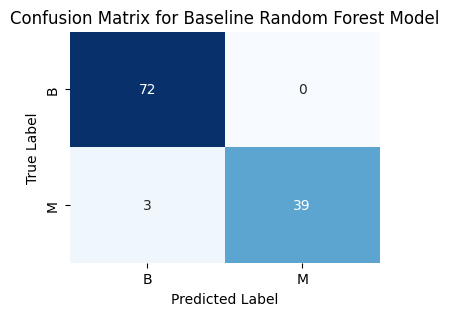

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tuned)
print(f"Confusion Matrix (Raw):\n{cm}")

# Plot Confusion Matrix 
plt.figure(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix for Baseline Random Forest Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

#### Interpretation:


- **True Negatives (TN = 72)**: 72 instances that were truly Benign were correctly predicted as Benign. The model has perfect recall for the Benign class.

- **False Positives (FP = 0)**: 0 instances that were truly Benign were incorrectly predicted as Malignant.

- **False Negatives (FN = 3)**: 3 instances that were truly Malignant were incorrectly predicted as Benign (a critical type of error in cancer diagnosis).

- **True Positives (TP = 39)**: 39 instances that were truly Malignant were correctly predicted as Malignant.

**The visualization of this matrix is shown in the image, which confirms a very strong performance, particularly in avoiding False Positives.**